In [3]:
import sys
import os
from pathlib import Path

ROOT_DIR = Path("..").resolve()
os.chdir(ROOT_DIR)

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.cleaning import DataCleaner
from src.eda import contract_churn, city_churn
from src.statistics import test_chi2_churn, test_ttest_churn

# Load and clean data
df_raw = load_data()
df = (
    DataCleaner(df_raw)
    .remove_duplicates()
    .clean_gender()
    .clean_city()
    .clean_monthly_charges()
    .clean_dates()
    .clean_negative_values()
    .fill_missing()
    .df
)

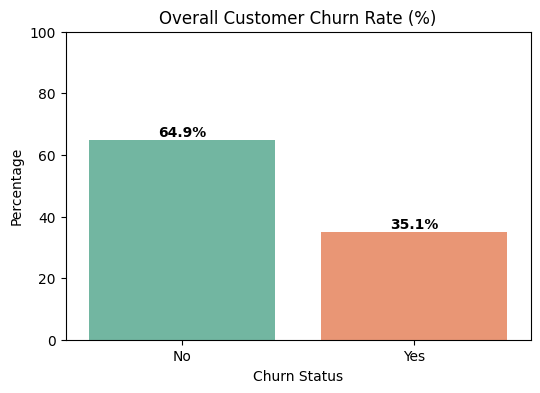

In [4]:
churn_counts = df["churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.barplot(
    x=churn_counts.index, 
    y=churn_counts.values, 
    hue=churn_counts.index,  # Fixes the warning
    legend=False,             # Prevents unnecessary duplicate legend
    palette="Set2"
)
plt.title("Overall Customer Churn Rate (%)")
plt.ylabel("Percentage")
plt.xlabel("Churn Status")

for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.ylim(0, 100)
plt.show()

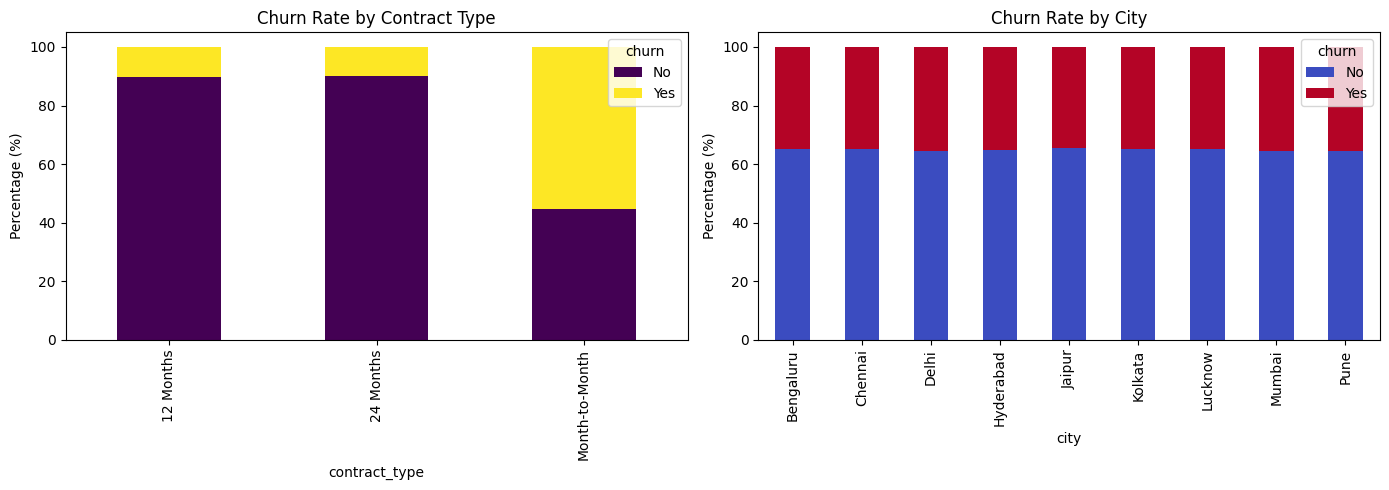

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract Churn
contract_df = contract_churn(df)
contract_df.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Percentage (%)")

# City Churn
city_df = city_churn(df)
city_df.plot(kind="bar", stacked=True, ax=axes[1], colormap="coolwarm")
axes[1].set_title("Churn Rate by City")
axes[1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

In [7]:
# 1. Chi-Square Test: Contract Type vs Churn
chi2_res = test_chi2_churn(df, "contract_type", "churn")

print("--- CHI-SQUARE TEST: Contract Type vs Churn ---")
print(f"Chi2 Statistic: {chi2_res['Chi2 Statistic']:.4f}")
print(f"p-value: {chi2_res['p-value']:.4e}")
print(f"Degrees of Freedom: {chi2_res['Degrees of Freedom']}\n")

# 2. Welch's T-Test: Monthly Charges by Churn Status
ttest_res = test_ttest_churn(df, "monthly_charges", "churn")

print("--- WELCH'S T-TEST: Monthly Charges by Churn ---")
print(f"T-Statistic: {ttest_res['t-statistic']:.4f}")
print(f"p-value: {ttest_res['p-value']:.4e}")

--- CHI-SQUARE TEST: Contract Type vs Churn ---
Chi2 Statistic: 44646.3260
p-value: 0.0000e+00
Degrees of Freedom: 2

--- WELCH'S T-TEST: Monthly Charges by Churn ---
T-Statistic: 0.2367
p-value: 8.1292e-01
